# Step 5a -- explicit regularisation on the given-background PINN

The step-4a field (fixed given background, `n_bkg=0`) with step 5's explicit penalties
added to the loss -- but on the **cloud fields only**:

$$\mathcal{L} = \chi^2 + \mathcal{R}_\mathrm{smooth} + \mathcal{R}_\mathrm{bound}\qquad(\text{no background terms}).$$

Because the background is fixed (0 DoF), step 5's whole *background-control* machinery is
gone: **no** PCA-coeff smoothing, **no** `no_emission` cap, **no** anchor. What remains is
autograd space+time smoothness and per-parameter soft hinges on the 8 free cloud fields --
the levers that tame the 4a runaway tails (`vlos1 -> -128`, `dv1 -> 68`). Reuses
`regularizers.py` verbatim (now `n_bkg`-aware). Config-driven; scale to the server as before.

In [1]:
import sys, os
sys.path.insert(0, '..')          # cloud_model_torch.py / utils.py (repo root)

import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from pinn_model import ParameterField, grid_coords
from composite_model import composite_synth_given, chi2_per_pixel
from given_background import load_given_background_window, default_bkg_path
from regularizers import regularization_loss, expand_group_config, field_layout

%load_ext autoreload
%autoreload 2

In [3]:
# ---- configuration: compact, laptop-scale (given-background PINN + regularisation) ----
N_BASIS = 10       # trailing snapshots used only to define Iqs
LAM     = slice(100, 500)

# fit window
T0   = 13
N_T  = 3           # frames -> exercises the TEMPORAL smoothness term (raise for more)
CROP = 64          # CROP x CROP spatial crop

FREEZE = ("loga1", "loga2")   # cloud params held at init (drop out of the field + reg)

# neural field. Bandwidths live in NORMALISED [-1,1] coords, so scale them with the
# window (crop_ref=40 -> sigma_xy=4 ; n_t_ref=4 -> sigma_t=2) to hold the per-pixel /
# per-frame smoothness fixed as CROP / N_T change (see step_4a_outline sec. 6).
N_FREQ   = 128
CROP_REF = 40; SIGMA_XY_REF = 4.0
N_T_REF  = 4;  SIGMA_T_REF  = 2.0
SIGMA_XY = SIGMA_XY_REF * CROP / CROP_REF
SIGMA_T  = SIGMA_T_REF  * N_T  / N_T_REF
WIDTH    = 256
DEPTH    = 4
S_MAX    = 1.0
DV_FLOOR = 8.0

# training (cosine-annealed Adam)
N_ITERS   = 1500
LR        = 5e-3
GRAD_CLIP = 1.0
BATCH     = None   # None = full batch; int = minibatch over coordinates

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
_CANDS = ['/dat/milic/MiHI_filament/mihi_all_data.npz',
          '/home/milic/data/MiHI_halpha_filament/mihi_all_data.npz']
DATA_NPZ = next((p for p in _CANDS if os.path.exists(p)), _CANDS[0])
BKG_NPZ  = default_bkg_path(DATA_NPZ)
device   = torch.device(DEVICE)
print("device:", device, "| data:", DATA_NPZ)
print("SIGMA_XY %.2f (CROP %d)  |  SIGMA_T %.2f (N_T %d)" % (SIGMA_XY, CROP, SIGMA_T, N_T))

device: cuda | data: /dat/milic/MiHI_filament/mihi_all_data.npz
SIGMA_XY 6.40 (CROP 64)  |  SIGMA_T 1.50 (N_T 3)


In [4]:
# Hard set the sigmas if you prefer: 
SIGMA_XY = 8.0
SIGMA_T = 2.0

In [ ]:
# ---- REG: explicit regularisation config (CLOUD fields only; the thing to scan) ----
# No background here (n_bkg=0), so step 5's 'bkg' smoothing / 'no_emission' / 'anchor'
# are all absent. Per cloud group:
#   w_xy / w_t         : autograd space / time smoothness   w * <|grad p|^2>
#   lo/hi + w_lo/w_hi   : soft one-sided quadratic hinges     w * <ReLU(.)^2>
# The field transforms already enforce S in [0,S_MAX], dtau>=0, dv>=DV_FLOOR, so the
# load-bearing NEW terms are the vlos RANGE hinge and the dv UPPER cap -- exactly what
# removes the 4a runaway tails -- plus light space+time smoothing (strongest on the
# weakly-constrained vlos1). Starting point; scan the weights.
REG = {
    'S':    dict(w_xy=1e-3, w_t=1e-2, lo=0.0,   w_lo=1e-2, hi=0.6, w_hi=1e-2),   # >=0 backstop
    'dtau': dict(w_xy=1e-3, w_t=1e-3, lo=0.0,   w_lo=1e-2),
    'vlos': dict(w_xy=1e-3, w_t=2e-3, lo=-120.0, hi=120.0, w_lo=1e-2, w_hi=1e-2),  # tame runaway velocities
    'dv':   dict(w_xy=1e-3, w_t=1e-3, hi=45.0,  w_hi=1e-2),   # cap over-broadening
}
regw = expand_group_config(REG, n_bkg=0)   # -> per-field (8,) vectors, expanded once
print('cloud fields:', field_layout(0)[0])
print('w_xy        :', regw['w_xy'].numpy().round(4))
print('vlos hinge  : [%.0f, %.0f]   dv cap: %.0f' %
      (float(regw['lo'][2]), float(regw['hi'][2]), float(regw['hi'][3])))

cloud fields: ['S1', 'dtau1', 'vlos1', 'dv1', 'S2', 'dtau2', 'vlos2', 'dv2']
w_xy        : [0.001 0.001 0.003 0.001 0.001 0.001 0.003 0.001]
vlos hinge  : [-60, 60]   dv cap: 45


In [7]:
# ---- load cube once; carve the fit window; load the SAME-window given background ----
f    = np.load(DATA_NPZ, allow_pickle=True)
wav  = np.asarray(f['wav'])
cube = f['data']                                             # (t, y, x, lambda)

YS, XS = slice(15, -15), slice(15, -15)
blk = np.copy(cube[-N_BASIS:, YS, XS, LAM]).astype(np.float32)
Iqs = float(blk[..., -20:].mean())

full   = cube[:, YS, XS, LAM]
Ny, Nx = full.shape[1], full.shape[2]
cy, cx = Ny // 2, Nx // 2
ys = slice(cy - CROP // 2, cy - CROP // 2 + CROP)
xs = slice(cx - CROP // 2, cx - CROP // 2 + CROP)
ts = list(range(T0 - N_T // 2, T0 - N_T // 2 + N_T))
obs = np.copy(full[ts][:, ys, xs, :]).astype(np.float32) / Iqs
del f, cube, full

Nt, Cy, Cx, L = obs.shape
xl  = [np.copy(wav[LAM]).astype(np.float32), np.asarray([np.mean(wav[LAM])], dtype=np.float32)]

obs_pt = torch.from_numpy(obs.reshape(-1, L)).to(device)
# coordinates MUST carry requires_grad -> the autograd smoothness penalty differentiates
# the fields w.r.t. them (in minibatch mode a fresh grad leaf is made each step).
coords = grid_coords(Nt, Cy, Cx, device=device).requires_grad_(True)

I_in, bshape = load_given_background_window(BKG_NPZ, ts, YS, XS, LAM, ys, xs, Iqs, device=device)
assert I_in.shape == obs_pt.shape and not I_in.requires_grad
print("frames:", ts, "| crop:", (Cy, Cx), "| N samples:", coords.shape[0], "| L:", L)
print("I_in:", tuple(I_in.shape), "| bg free params: 0 | mean=%.4f" % float(I_in.mean()))

frames: [12, 13, 14] | crop: (64, 64) | N samples: 12288 | L: 400
I_in: (12288, 400) | bg free params: 0 | mean=0.6837


In [8]:
# ---- neural field (n_bkg=0, given background): predicts the free cloud params ----
field = ParameterField(d_in=3, n_freq=N_FREQ, sigmas=(SIGMA_XY, SIGMA_XY, SIGMA_T),
                       width=WIDTH, depth=DEPTH, s_max=S_MAX, dv_floor=DV_FLOOR,
                       n_bkg=0, freeze=FREEZE).to(device)
print("frozen:", FREEZE, "| head out:", field.head.out_features,
      "| field weights:", sum(p.numel() for p in field.parameters()))
with torch.no_grad():
    _, pc0 = field(coords)
    _, l0  = chi2_per_pixel(obs_pt, composite_synth_given(xl, I_in, pc0, loga_clamp=None), reduce_mean=True)
print("init cloud means [S1,tau1,v1,dv1,loga1,S2,tau2,v2,dv2,loga2]:",
      pc0.mean(0).cpu().numpy().round(2))
print("initial chi2:", round(float(l0), 4))

frozen: ('loga1', 'loga2') | head out: 8 | field weights: 265224
init cloud means [S1,tau1,v1,dv1,loga1,S2,tau2,v2,dv2,loga2]: [  0.2    4.5  -20.01  12.    -4.     0.6    4.5   20.02  12.    -5.  ]
initial chi2: 6.4918


In [9]:
# ---- gradient + reg check: loss -> weights; reg parts finite; frozen slots constant ----
for p in field.parameters():
    p.grad = None
c, pc = field(coords)
_, data = chi2_per_pixel(obs_pt, composite_synth_given(xl, I_in, pc, loga_clamp=None), reduce_mean=True)
reg = regularization_loss(c, pc, coords, weights=regw)      # pca=None, c_ref=None -> clouds only
(data + reg['total']).backward()
names = ['S1','dtau1','vlos1','dv1','loga1','S2','dtau2','vlos2','dv2','loga2']
coln  = {n: i for i, n in enumerate(names)}
n_grad = sum(int(p.grad is not None) for p in field.parameters())
print("data chi2: %.4f | reg smooth=%.3e bound=%.3e (no_emission/anchor=0)"
      % (float(data), float(reg['smooth']), float(reg['bound'])))
print("params with grad:", n_grad, "/", sum(1 for _ in field.parameters()),
      "| frozen", FREEZE, "constant:",
      all(bool((pc[:, coln[k]] == pc[0, coln[k]]).all()) for k in FREEZE))

data chi2: 6.4918 | reg smooth=8.340e-05 bound=0.000e+00 (no_emission/anchor=0)
params with grad: 10 / 10 | frozen ('loga1', 'loga2') constant: True


/tmp/ipykernel_852657/75539354.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  % (float(data), float(reg['smooth']), float(reg['bound'])))


  0%|          | 0/10000 [00:00<?, ?it/s]

total 6.4918e+00 -> 2.3719e-01 | data(chi2) 2.3380e-01 | reg 3.3893e-03 | 363.2 s, 36.3 ms/iter


Text(0.5, 1.0, 'given-background PINN loss (step 5a)')

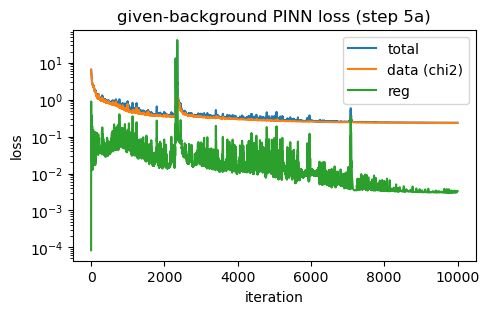

In [10]:
# ---- train: chi2 + regularisation (cosine-annealed Adam, grad clip, timed) ----
from tqdm.auto import trange
from torch.optim.lr_scheduler import CosineAnnealingLR

# Adjust again the training parameters if you need to:
# training (cosine-annealed Adam)
N_ITERS   = 10000
LR        = 5e-3
GRAD_CLIP = 1.0
BATCH     = None   # None = full batch; int = minibatch over coordinates

opt   = torch.optim.Adam(field.parameters(), lr=LR)
sched = CosineAnnealingLR(opt, T_max=N_ITERS, eta_min=LR * 0.05)
hist, hist_data, hist_reg = [], [], []
n = coords.shape[0]
t_start = time.time()
for it in trange(N_ITERS):
    opt.zero_grad()
    if BATCH is None:
        cb, ob, ib = coords, obs_pt, I_in                 # coords already carries requires_grad
    else:
        idx = torch.randint(0, n, (BATCH,), device=device)
        cb  = coords[idx].detach().requires_grad_(True)   # clean leaf for autograd smoothness
        ob, ib = obs_pt[idx], I_in[idx]
    c, pc = field(cb)
    _, data = chi2_per_pixel(ob, composite_synth_given(xl, ib, pc, loga_clamp=None), reduce_mean=True)
    reg  = regularization_loss(c, pc, cb, weights=regw)
    loss = data + reg['total']
    if not torch.isfinite(loss):
        print('non-finite loss at iter', it, '-- stopping'); break
    loss.backward()
    torch.nn.utils.clip_grad_norm_(field.parameters(), GRAD_CLIP)
    opt.step(); sched.step()
    hist.append(float(loss)); hist_data.append(float(data)); hist_reg.append(float(reg['total']))
dt = time.time() - t_start; ms = 1e3 * dt / max(len(hist), 1)
print('total %.4e -> %.4e | data(chi2) %.4e | reg %.4e | %.1f s, %.1f ms/iter'
      % (hist[0], hist[-1], hist_data[-1], hist_reg[-1], dt, ms))
plt.figure(figsize=(5.2, 3))
plt.semilogy(hist, label='total'); plt.semilogy(hist_data, label='data (chi2)'); plt.semilogy(hist_reg, label='reg')
plt.legend(); plt.xlabel('iteration'); plt.ylabel('loss'); plt.title('given-background PINN loss (step 5a)')

In [11]:
# ---- QUANTITATIVE SUMMARY: chi2 stays near noise, cloud ranges now PHYSICAL ----
with torch.no_grad():
    _, p_all = field(coords)
    syn = composite_synth_given(xl, I_in, p_all, loga_clamp=None)
resid   = obs_pt - syn
chi2v   = (resid ** 2).sum(-1)
rms_pct = 100.0 * float(torch.sqrt((resid ** 2).mean())) / float(obs_pt.mean())
print("final mean per-pixel chi2: %.4f | median: %.4f | p95: %.4f"
      % (float(chi2v.mean()), float(chi2v.median()), float(torch.quantile(chi2v, 0.95))))
print("RMS residual: %.2f %% of mean intensity" % rms_pct)
pa = p_all.cpu().numpy()
print("\n  param      min    median      max     (4a had vlos1 -128..44, dv1 8..68)")
for j, nm in enumerate(names):
    print("  %-7s %8.3f %8.3f %8.3f" % (nm, pa[:, j].min(), np.median(pa[:, j]), pa[:, j].max()))
core = L // 2
oco, ico = float(obs_pt[:, core-20:core+20].mean()), float(I_in[:, core-20:core+20].mean())
print("\ncore (idx %d): obs=%.4f  I_in=%.4f  -> I_in above core: %s" % (core, oco, ico, ico > oco))

final mean per-pixel chi2: 0.2338 | median: 0.1771 | p95: 0.5576
RMS residual: 3.82 % of mean intensity

  param      min    median      max     (4a had vlos1 -128..44, dv1 8..68)
  S1         0.000    0.143    0.849
  dtau1      0.000    0.490   76.681
  vlos1    -61.937  -25.416   -8.248
  dv1       12.095   22.716   45.631
  loga1     -4.000   -4.000   -4.000
  S2         0.010    0.364    0.618
  dtau2      0.000    0.289    8.720
  vlos2    -14.013   18.303   31.483
  dv2        9.850   12.013   40.981
  loga2     -5.000   -5.000   -5.000

core (idx 200): obs=0.2758  I_in=0.3050  -> I_in above core: True


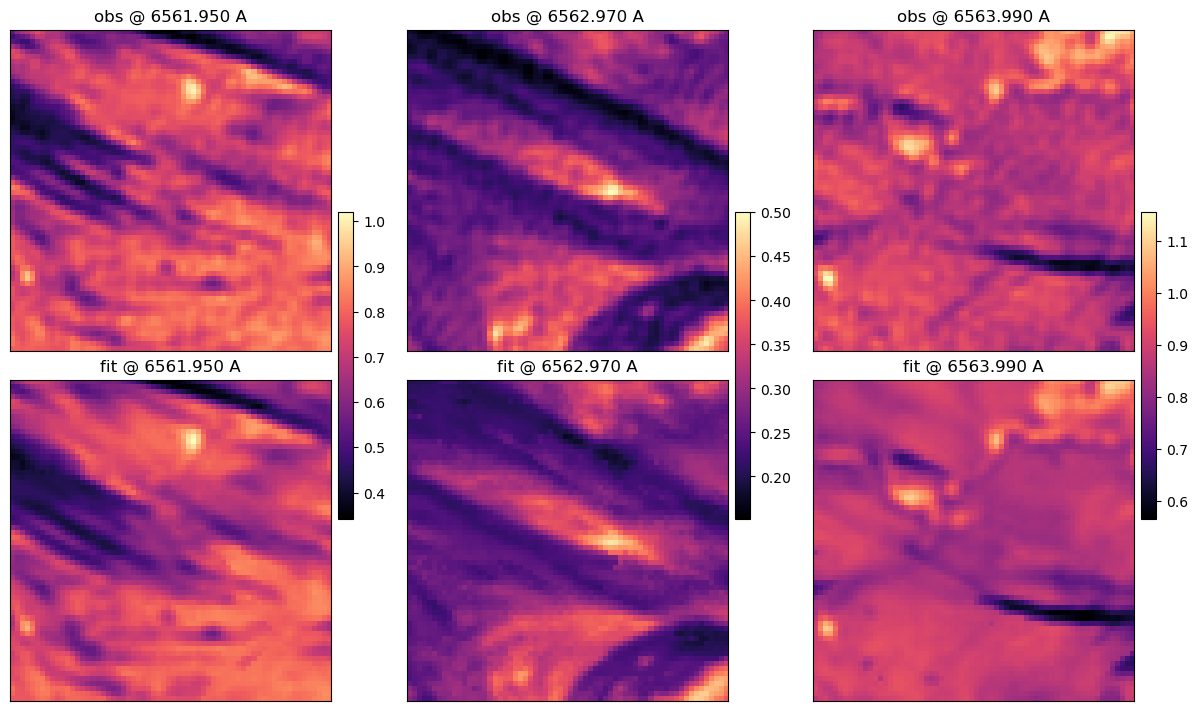

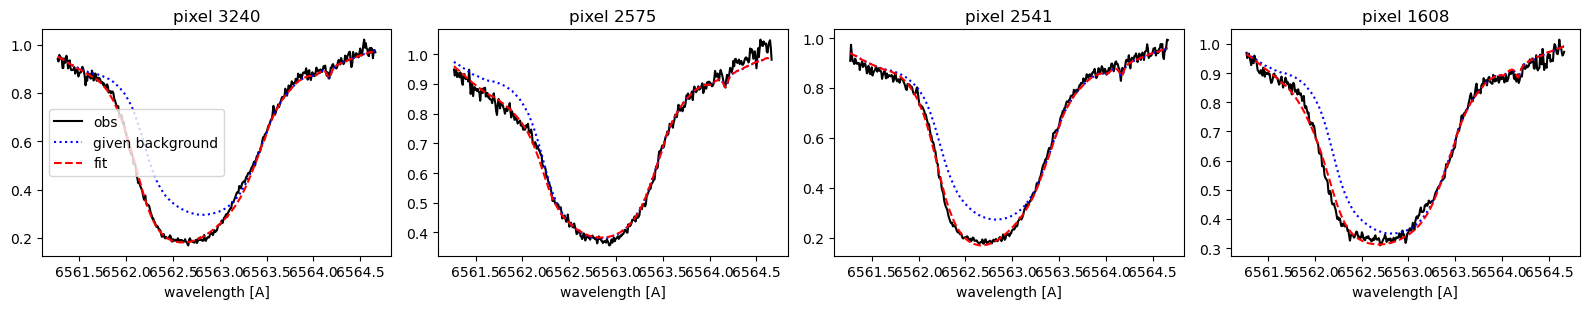

In [12]:
# ---- obs vs fit image maps (centre frame) + a few pixel spectra; save a PDF ----
os.makedirs('../figs', exist_ok=True)
kf = Nt // 2; wl = wav[LAM]
oc = obs_pt.cpu().numpy().reshape(Nt, Cy, Cx, L)[kf]
fc = syn.cpu().numpy().reshape(Nt, Cy, Cx, L)[kf]
bc = I_in.cpu().numpy().reshape(Nt, Cy, Cx, L)[kf]
wl_idx = [max(core - 120, 0), core, min(core + 120, L - 1)]
fig, ax = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for j, ii in enumerate(wl_idx):
    vmn = min(oc[:, :, ii].min(), fc[:, :, ii].min()); vmx = max(oc[:, :, ii].max(), fc[:, :, ii].max())
    ax[0, j].imshow(oc[:, :, ii].T, origin='lower', cmap='magma', vmin=vmn, vmax=vmx)
    im = ax[1, j].imshow(fc[:, :, ii].T, origin='lower', cmap='magma', vmin=vmn, vmax=vmx)
    ax[0, j].set_title('obs @ %.3f A' % wl[ii]); ax[1, j].set_title('fit @ %.3f A' % wl[ii])
    for a in (ax[0, j], ax[1, j]):
        a.set_xticks([]); a.set_yticks([])
    fig.colorbar(im, ax=[ax[0, j], ax[1, j]], fraction=0.046, pad=0.02)
plt.savefig('../figs/step_5a_pinn_fit_images.pdf', dpi=200)

o2, f2, b2 = oc.reshape(-1, L), fc.reshape(-1, L), bc.reshape(-1, L)
np.random.seed(2); ii = np.random.randint(0, Cy * Cx, size=4)
fig, ax = plt.subplots(1, 4, figsize=(16, 3.2))
for j, p in enumerate(ii):
    ax[j].plot(wl, o2[p], 'k',  label='obs')
    ax[j].plot(wl, b2[p], 'b:', label='given background')
    ax[j].plot(wl, f2[p], 'r--', label='fit')
    ax[j].set_title('pixel %d' % p); ax[j].set_xlabel('wavelength [A]')
ax[0].legend(); plt.tight_layout()

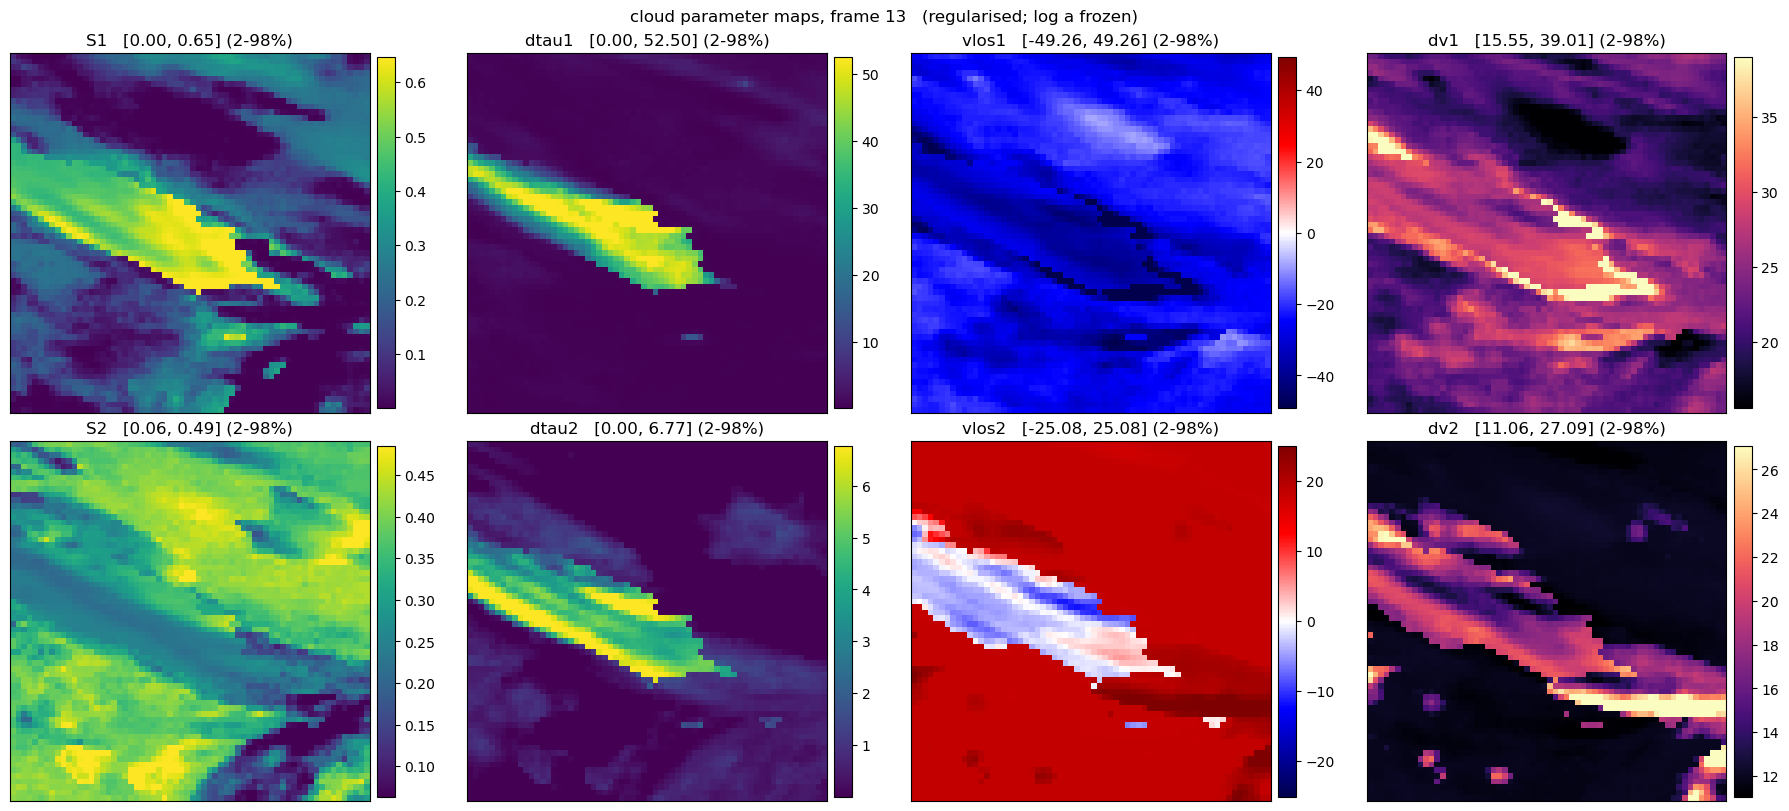

In [13]:
# ---- comprehensive cloud-parameter maps (centre frame), robust colour limits ----
# Compare against the 4a maps: the vlos / dv panels should be smoother and free of the
# runaway pixels now that the hinges + space/time smoothing are active.
pm = p_all.cpu().numpy().reshape(Nt, Cy, Cx, 10)[kf]
specs = [('S1', 0, 'viridis'), ('dtau1', 1, 'viridis'), ('vlos1', 2, 'seismic'), ('dv1', 3, 'magma'),
         ('S2', 5, 'viridis'), ('dtau2', 6, 'viridis'), ('vlos2', 7, 'seismic'), ('dv2', 8, 'magma')]
fig, ax = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True); ax = ax.ravel()
for k, (nm, j, cmap) in enumerate(specs):
    im2 = pm[:, :, j].T
    lo, hi = np.percentile(im2, [2, 98])
    if cmap == 'seismic':
        m = max(abs(lo), abs(hi)); lo, hi = -m, m
    h = ax[k].imshow(im2, origin='lower', cmap=cmap, vmin=lo, vmax=hi)
    ax[k].set_title('%s   [%.2f, %.2f] (2-98%%)' % (nm, lo, hi))
    ax[k].set_xticks([]); ax[k].set_yticks([])
    fig.colorbar(h, ax=ax[k], fraction=0.046, pad=0.02)
fig.suptitle('cloud parameter maps, frame %d   (regularised; log a frozen)' % ts[kf])
plt.savefig('../figs/step_5a_pinn_param_maps.pdf', dpi=150)

## Notes

- **What is regularised:** the 8 free cloud fields only. `regularizers.py` runs in its
  `n_bkg=0` mode, so `assemble_fields` yields the 8 cloud columns and `no_emission` /
  `anchor` are inert (`pca=None`, `c_ref=None`). The loss is `chi2 + smooth + bound`.
- **The load-bearing terms** here are the `vlos` range hinge and the `dv` upper cap
  (the field transforms already give `S`, `dtau`, `dv` their positivity / floor), plus
  light space+time smoothing -- strongest on the weakly-constrained `vlos1`. This is what
  removes the 4a runaway tails while keeping `chi2` near the noise floor.
- **Scan the weights** (`w_xy`, `w_t`, `w_lo`, `w_hi`) -- the balance vs the `chi2` scale
  is the real work: watch the `vlos`/`dv` ranges tighten in the summary and the maps
  smooth out, without `chi2` rising much.
- **Off-core is still background-limited** (unchanged from 4a): the clouds own the core,
  the fixed given background owns the wings.
- **Optional (step-5 parity):** relax the strict `S` transform to positivity-only so the
  hinge owns the upper bound; not needed for the velocity/width taming that matters here.
- **Scale to the server:** raise `CROP`/`N_T`/`WIDTH`, set `BATCH` (a fresh grad leaf is
  made per step, so smoothness still works), `device=cuda`. Same code.